
# CheXpert Plus — Comprehensive EDA

This notebook is the **master EDA notebook for CheXpert Plus**.

### Completed separately
EDA for the three report-derived label sets has already been prepared in:

- `chexpert_plus_report_eda.ipynb`
- `chexpert_plus_findings_eda.ipynb`
- `chexpert_plus_impression_eda.ipynb`

This notebook therefore focuses on the **remaining dataset-level, patient/study-level, imaging-metadata, demographic, administrative, integrity, and leakage analyses**, while providing optional hooks for joining the completed label analyses.

### CheXpert Plus metadata used here

The provided metadata schema contains **223,462 rows and 27 variables**, including:

- image and DICOM paths
- projection/orientation
- de-identified patient ID
- report and report sections
- age, sex, race, ethnicity
- interpreter requirement
- insurance type
- recent BMI
- deceased status
- split

The exact report fields include `report`, `section_findings`, and `section_impression`.

> **Important:** This notebook does not recreate your completed Findings/Impression/Report EDA. It uses those analyses as upstream components and adds the missing metadata/image/patient/study analysis.


In [1]:

# ============================================================
# 0. Configuration
# ============================================================
from pathlib import Path

# Main CheXpert Plus metadata file
CSV_PATH = Path("df_chexpert_plus_240401.csv")

# Optional local image root. Set to None or the correct directory.
IMAGE_ROOT = Path("PNG")

# Optional completed label-analysis CSVs, if you exported them.
REPORT_LABELS_PATH = None
FINDINGS_LABELS_PATH = None
IMPRESSION_LABELS_PATH = None

# Number of images to inspect for optional image EDA
IMAGE_SAMPLE_N = 500

# Reproducibility
RANDOM_STATE = 42


In [2]:

# ============================================================
# 1. Imports and display settings
# ============================================================
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 140)

print("Imports ready.")


Imports ready.


## 2. Load the exact CheXpert Plus metadata table

The metadata table should be the primary source for this notebook.

In [3]:

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Could not find: {CSV_PATH.resolve()}\n"
        "Set CSV_PATH to your local df_chexpert_plus_240401.csv."
    )

df = pd.read_csv(CSV_PATH, low_memory=False)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head(3))


Rows: 223,462
Columns: 27


,path_to_image,path_to_dcm,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,section_narrative,section_clinical_history,section_history,section_comparison,section_technique,section_procedure_comments,section_findings,section_impression,section_end_of_impression,section_summary,section_accession_number,age,sex,race,ethnicity,interpreter_needed,insurance_type,recent_bmi,deceased,split
0,train/patient00003/study1/view1_frontal.jpg,train/patient00003/study1/view1_frontal.dcm,Frontal,AP,patient00003,1,"NARRATIVE:\nCHEST, ONE VIEW: 2-10-2001\nFINDINGS: Costophrenic angles sharp, without evidence of effusion.\nThe cardiomediastinal silhou...","\nCHEST, ONE VIEW: 2-10-2001\n",NaN,NaN,NaN,NaN,NaN,"Costophrenic angles sharp, without evidence of effusion.\nThe cardiomediastinal silhouette is normal. Vessels mildly\nindistinct with p...",\n1. NO EVIDENCE OF PNEUMOTHORAX.\n2. MILD INTERSTITIAL PULMONARY EDEMA.\n,\n,2\nI have personally reviewed the images for this examination and agree\nwith the report transcribed above.\nBy: Dr. Juarez Tucker N o...,\nLFEWOZWVDRX\nThis report has been anonymized. All dates are offset from the actual dates by a fixed interval associated with the patient.,41.0,Male,White,Non-Hispanic/Non-Latino,Unknown,Private Insurance,NaN,No,train
1,train/patient00007/study2/view1_frontal.jpg,train/patient00007/study2/view1_frontal.dcm,Frontal,AP,patient00007,2,"NARRATIVE:\nChest 1 View: July 20\n \nHISTORY: Male, 69 years old, intubated.\n \nCOMPARISON: 7/20/2020.\n \nIMPRESSION: \n \nLow lung v...",\nChest 1 View: July 20\n \n,NaN,"Male, 69 years old, intubated.\n \n",7/20/2020.\n \n,NaN,NaN,NaN,\n \nLow lung volumes. Stable moderate enlargement of the \ncardiomediastinal silhouette. Normal pulmonary vascularity. Patchy \nopa...,NaN,"4-POSSIBLY SIGNIFICANT FINDING, MAY NEED ACTION\n \n",\n485K2I4588\nThis report has been anonymized. All dates are offset from the actual dates by a fixed interval associated with the patient.,69.0,Male,Other,Hispanic/Latino,No,Private Insurance,NaN,No,train
2,train/patient00007/study1/view1_frontal.jpg,train/patient00007/study1/view1_frontal.dcm,Frontal,AP,patient00007,1,"NARRATIVE:\nChest 1 View: 12-28-2000\n \nHISTORY: Male, 69 years old, Check tube placement.\n \nCOMPARISON: None.\n \nIMPRESSION: \n \nL...",\nChest 1 View: 12-28-2000\n \n,NaN,"Male, 69 years old, Check tube placement.\n \n",None.\n \n,NaN,NaN,NaN,"\n \nLow lung volumes, and overlying trauma board limit evaluation. There \nis prominence of the cardiac shadow, likely reflecting car...",NaN,"4-POSSIBLY SIGNIFICANT FINDING, MAY NEED ACTION \nI have personally reviewed the images for this examination and agreed\nwith the report...",\nRN\nThis report has been anonymized. All dates are offset from the actual dates by a fixed interval associated with the patient.,69.0,Male,Other,Hispanic/Latino,No,Private Insurance,NaN,No,train


## 3. Validate the expected 27-column schema

In [4]:

EXPECTED_COLUMNS = [
    "path_to_image",
    "path_to_dcm",
    "frontal_lateral",
    "ap_pa",
    "deid_patient_id",
    "patient_report_date_order",
    "report",
    "section_narrative",
    "section_clinical_history",
    "section_history",
    "section_comparison",
    "section_technique",
    "section_procedure_comments",
    "section_findings",
    "section_impression",
    "section_end_of_impression",
    "section_summary",
    "section_accession_number",
    "age",
    "sex",
    "race",
    "ethnicity",
    "interpreter_needed",
    "insurance_type",
    "recent_bmi",
    "deceased",
    "split",
]

missing = [c for c in EXPECTED_COLUMNS if c not in df.columns]
unexpected = [c for c in df.columns if c not in EXPECTED_COLUMNS]

print("Missing expected columns:", missing if missing else "None")
print("Unexpected columns:", unexpected if unexpected else "None")

if not missing and not unexpected and df.shape[1] == 27:
    print("Schema matches the provided CheXpert Plus metadata structure.")


Missing expected columns: None
Unexpected columns: None
Schema matches the provided CheXpert Plus metadata structure.


## 4. Variable types and data quality

In [5]:

dtype_table = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "non_null": [df[c].notna().sum() for c in df.columns],
    "missing": [df[c].isna().sum() for c in df.columns],
})
dtype_table["missing_pct"] = dtype_table["missing"] / len(df) * 100

display(dtype_table.sort_values("missing_pct", ascending=False).round(2))


,column,dtype,non_null,missing,missing_pct
11,section_technique,str,10732,212730,95.20
12,section_procedure_comments,str,25669,197793,88.51
9,section_history,str,38192,185270,82.91
13,section_findings,str,59469,163993,73.39
15,section_end_of_impression,str,73738,149724,67.00
8,section_clinical_history,str,138866,84596,37.86
24,recent_bmi,float64,164985,58477,26.17
16,section_summary,str,189648,33814,15.13
3,ap_pa,str,191071,32391,14.50
10,section_comparison,str,213125,10337,4.63


## 5. Missingness analysis for metadata

Missingness is analyzed here as a **data-quality property**. Do not automatically interpret a missing value as a negative clinical finding.

,missing_count,missing_pct
section_technique,212730,95.20
section_procedure_comments,197793,88.51
section_history,185270,82.91
section_findings,163993,73.39
section_end_of_impression,149724,67.00
section_clinical_history,84596,37.86
recent_bmi,58477,26.17
section_summary,33814,15.13
ap_pa,32391,14.50
section_comparison,10337,4.63


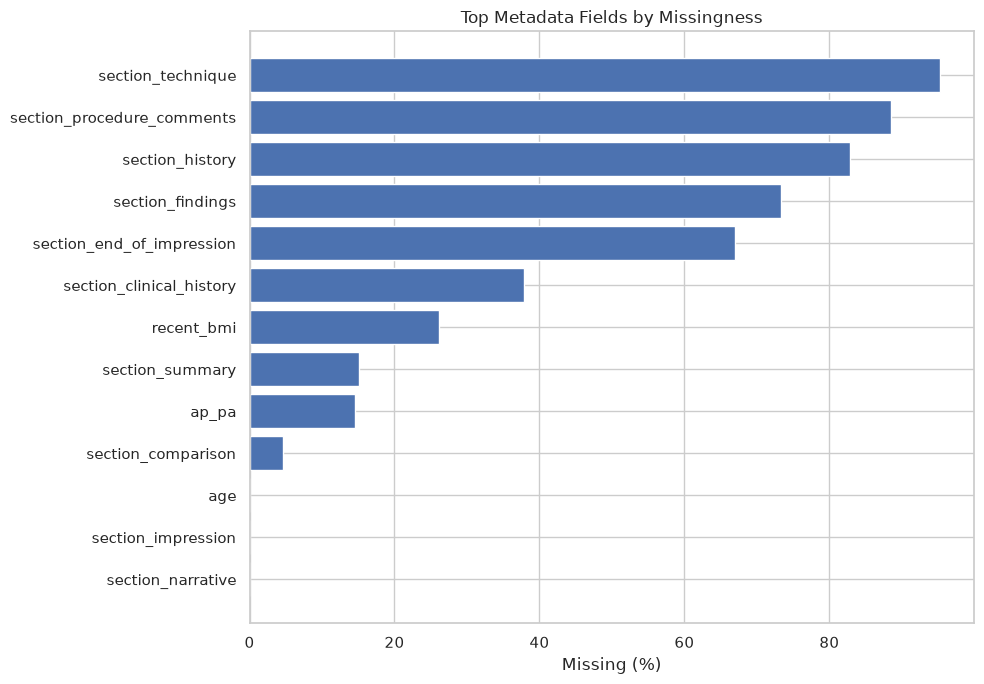

In [6]:

missing_summary = (
    df.isna().sum()
      .rename("missing_count")
      .to_frame()
      .assign(
          missing_pct=lambda x: x["missing_count"] / len(df) * 100
      )
      .sort_values("missing_pct", ascending=False)
)

display(missing_summary.round(2))

plt.figure(figsize=(10, 7))
plot_data = missing_summary[missing_summary["missing_count"] > 0].head(20)
plt.barh(plot_data.index[::-1], plot_data["missing_pct"].values[::-1])
plt.xlabel("Missing (%)")
plt.title("Top Metadata Fields by Missingness")
plt.tight_layout()
plt.show()


## 6. Image → study → patient hierarchy

In [7]:

# Primary hierarchy fields available directly in the metadata.
# patient_report_date_order helps distinguish repeated reports/studies chronologically.

df["deid_patient_id"] = df["deid_patient_id"].astype("string")

print("Unique patients:", df["deid_patient_id"].nunique(dropna=True))
print("Image rows:", len(df))

patient_image_counts = (
    df.groupby("deid_patient_id", dropna=True)
      .size()
      .rename("n_images")
)

display(patient_image_counts.describe().to_frame())


Unique patients: 64725
Image rows: 223462


,n_images
count,64725.000000
mean,3.452484
std,4.651210
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,92.000000


### Patient-level image-count distribution

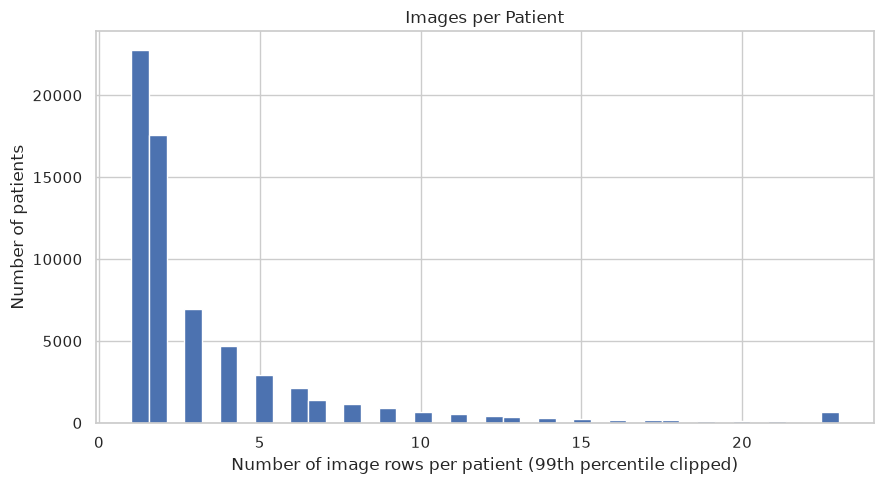

In [8]:

plt.figure(figsize=(9, 5))
plt.hist(
    patient_image_counts.clip(upper=patient_image_counts.quantile(0.99)),
    bins=40
)
plt.xlabel("Number of image rows per patient (99th percentile clipped)")
plt.ylabel("Number of patients")
plt.title("Images per Patient")
plt.tight_layout()
plt.show()


In [9]:

# Check whether path_to_image is unique.
duplicate_image_paths = df["path_to_image"].duplicated().sum()

print(f"Duplicate path_to_image rows: {duplicate_image_paths:,}")

# Study identifiers can be extracted from the documented path pattern.
path_pattern = re.compile(
    r"(?P<split>[^/]+)/patient(?P<patient>\d+)/study(?P<study>\d+)/"
    r"view(?P<view>\d+)_(?P<orientation>frontal|lateral)"
)

parsed = df["path_to_image"].astype("string").str.extract(path_pattern)

for col in parsed.columns:
    parsed[col] = parsed[col].astype("string")

df["path_split"] = parsed["split"]
df["path_patient_id"] = parsed["patient"]
df["path_study_id"] = parsed["study"]
df["path_view_id"] = parsed["view"]
df["path_orientation"] = parsed["orientation"]

print("Rows matching expected image-path structure:",
      df["path_patient_id"].notna().sum())
display(df[
    ["path_to_image", "deid_patient_id", "path_split",
     "path_patient_id", "path_study_id", "path_view_id",
     "path_orientation"]
].head(10))


Duplicate path_to_image rows: 0
Rows matching expected image-path structure: 223462


,path_to_image,deid_patient_id,path_split,path_patient_id,path_study_id,path_view_id,path_orientation
0,train/patient00003/study1/view1_frontal.jpg,patient00003,train,00003,1,1,frontal
1,train/patient00007/study2/view1_frontal.jpg,patient00007,train,00007,2,1,frontal
2,train/patient00007/study1/view1_frontal.jpg,patient00007,train,00007,1,1,frontal
3,train/patient00009/study1/view2_lateral.jpg,patient00009,train,00009,1,2,lateral
4,train/patient00009/study1/view1_frontal.jpg,patient00009,train,00009,1,1,frontal
5,train/patient00016/study1/view2_lateral.jpg,patient00016,train,00016,1,2,lateral
6,train/patient00016/study1/view1_frontal.jpg,patient00016,train,00016,1,1,frontal
7,train/patient00021/study1/view1_frontal.jpg,patient00021,train,00021,1,1,frontal
8,train/patient00026/study1/view1_frontal.jpg,patient00026,train,00026,1,1,frontal
9,train/patient00026/study1/view2_lateral.jpg,patient00026,train,00026,1,2,lateral


## 7. Study-level structure and number of images per study

In [10]:

# Use the path-derived patient/study IDs when available.
study_counts = (
    df.dropna(subset=["path_patient_id", "path_study_id"])
      .groupby(["path_patient_id", "path_study_id"])
      .size()
      .rename("n_images")
)

print(f"Unique studies from image paths: {len(study_counts):,}")
display(study_counts.describe().to_frame())

print("\nDistribution of number of images per study:")
display(
    study_counts.value_counts()
    .sort_index()
    .rename_axis("n_images")
    .to_frame("n_studies")
)


Unique studies from image paths: 187,711


,n_images
count,187711.000000
mean,1.190458
std,0.416087
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,3.000000



Distribution of number of images per study:


,n_studies
n_images,
1,153738
2,32195
3,1778


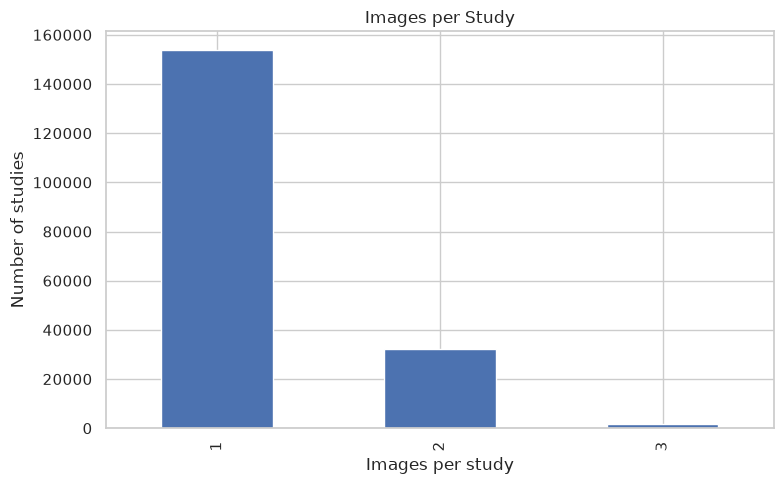

In [11]:

plt.figure(figsize=(8, 5))
study_counts.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Images per study")
plt.ylabel("Number of studies")
plt.title("Images per Study")
plt.tight_layout()
plt.show()


## 8. Split distribution and patient-level leakage checks

The metadata includes a ready-made `split` field. We still verify that patients do not cross splits.

In [12]:

if "split" in df.columns:
    split_counts = df["split"].value_counts(dropna=False)
    display(split_counts.rename("image_rows").to_frame())

    patient_split = (
        df.groupby("deid_patient_id")["split"]
          .nunique(dropna=True)
    )

    multi_split_patients = (patient_split > 1).sum()

    print(f"Patients appearing in more than one split: {multi_split_patients:,}")
    display(
        patient_split.value_counts()
        .sort_index()
        .rename_axis("number_of_splits")
        .to_frame("patients")
    )


,image_rows
split,
train,223228
valid,234


Patients appearing in more than one split: 0


,patients
number_of_splits,
1,64725


In [13]:

# Cross-tabulation of patient membership by split.
# Each row is a patient; columns are splits.
if "split" in df.columns:
    patient_split_table = pd.crosstab(
        df["deid_patient_id"],
        df["split"]
    )
    print("Patients by split membership:")
    display(patient_split_table.sum(axis=0).to_frame("patients"))


Patients by split membership:


,patients
split,
train,223228
valid,234


## 9. Projection and view EDA

These fields describe whether an image is frontal/lateral and whether the frontal projection is AP/PA.

In [14]:

for col in ["frontal_lateral", "ap_pa"]:
    print(f"\n=== {col} ===")
    counts = df[col].value_counts(dropna=False)
    display(counts.rename("count").to_frame().assign(
        percentage=lambda x: x["count"] / len(df) * 100
    ).round(2))



=== frontal_lateral ===


,count,percentage
frontal_lateral,,
Frontal,191071,85.5
Lateral,32391,14.5



=== ap_pa ===


,count,percentage
ap_pa,,
AP,161622,72.33
NaN,32391,14.50
PA,29432,13.17
LL,16,0.01
RL,1,0.00


In [15]:

# Cross-tabulate orientation and projection.
projection_table = pd.crosstab(
    df["frontal_lateral"],
    df["ap_pa"],
    dropna=False
)
display(projection_table)


ap_pa,AP,LL,PA,RL,NaN
frontal_lateral,,,,,
Frontal,161622,16,29432,1,0
Lateral,0,0,0,0,32391


## 10. Demographic EDA

Age summary:


,age
count,223184.00
mean,60.39
std,17.77
min,0.00
25%,49.00
50%,62.00
75%,74.00
max,89.00


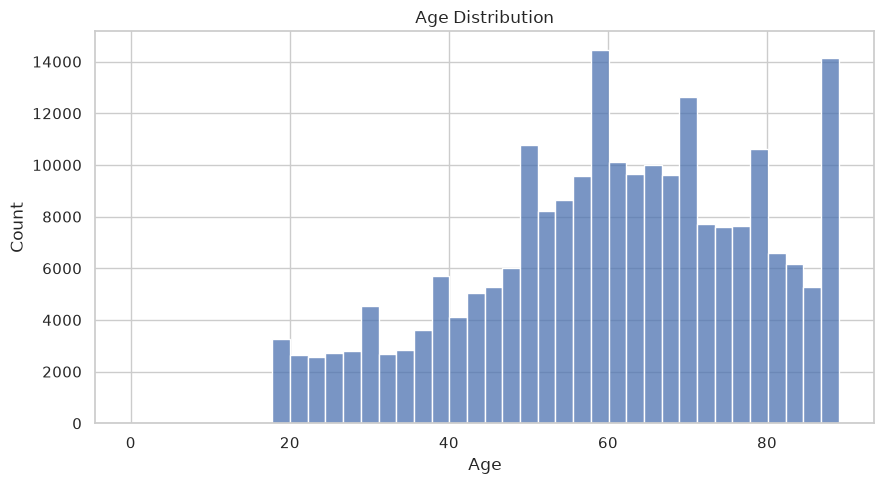

In [16]:

# Age cleaning / summary
age = pd.to_numeric(df["age"], errors="coerce")

print("Age summary:")
display(age.describe().to_frame("age").round(2))

if sns is not None:
    plt.figure(figsize=(9, 5))
    sns.histplot(age.dropna(), bins=40)
else:
    plt.figure(figsize=(9, 5))
    plt.hist(age.dropna(), bins=40)

plt.xlabel("Age")
plt.title("Age Distribution")
plt.tight_layout()
plt.show()


In [17]:

for col in ["sex", "race", "ethnicity"]:
    print(f"\n=== {col} ===")
    vc = df[col].value_counts(dropna=False)
    result = vc.rename("count").to_frame()
    result["percentage"] = result["count"] / len(df) * 100
    display(result.round(2).head(25))



=== sex ===


,count,percentage
sex,,
Male,132482,59.29
Female,90701,40.59
Unknown,279,0.12



=== race ===


,count,percentage
race,,
White,126669,56.68
Other,31561,14.12
Unknown,25370,11.35
Asian,23719,10.61
Black,12062,5.40
Pacific Islander,3180,1.42
Native American,547,0.24
Patient Refused,354,0.16



=== ethnicity ===


,count,percentage
ethnicity,,
Non-Hispanic/Non-Latino,169886,76.02
Hispanic/Latino,28222,12.63
Unknown,24947,11.16
Patient Refused,407,0.18


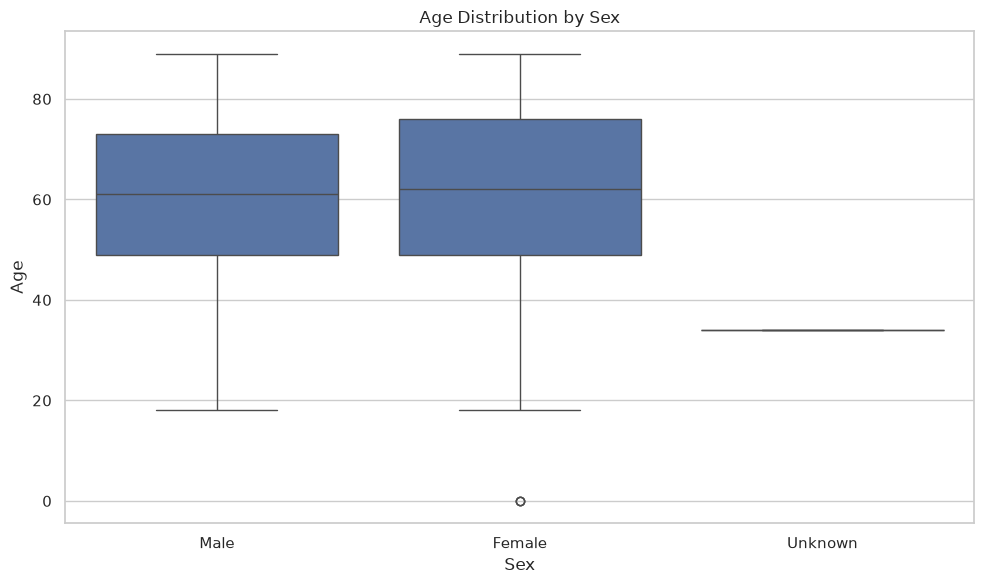

In [18]:

# Age by sex
temp = df[["age", "sex"]].copy()
temp["age"] = pd.to_numeric(temp["age"], errors="coerce")

plt.figure(figsize=(10, 6))
if sns is not None:
    sns.boxplot(data=temp.dropna(subset=["age"]), x="sex", y="age")
else:
    groups = [
        g["age"].dropna().values
        for _, g in temp.groupby("sex")
    ]
    labels = [str(k) for k, _ in temp.groupby("sex")]
    plt.boxplot(groups, labels=labels)

plt.title("Age Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Age")
plt.tight_layout()
plt.show()


## 11. Clinical and administrative metadata

In [19]:

for col in ["interpreter_needed", "insurance_type", "deceased"]:
    print(f"\n=== {col} ===")
    vc = df[col].value_counts(dropna=False)
    display(
        vc.rename("count")
          .to_frame()
          .assign(percentage=lambda x: x["count"] / len(df) * 100)
          .round(2)
    )



=== interpreter_needed ===


,count,percentage
interpreter_needed,,
No,165937,74.26
Unknown,39191,17.54
Yes,18334,8.20



=== insurance_type ===


,count,percentage
insurance_type,,
Medicare,107202,47.97
Private Insurance,49074,21.96
Unknown,41244,18.46
Medicaid,21499,9.62
Other,4443,1.99



=== deceased ===


,count,percentage
deceased,,
No,132037,59.09
Yes,91029,40.74
Unknown,396,0.18


Recent BMI summary:


,recent_bmi
count,164985.00
mean,26.73
std,6.51
min,0.00
25%,22.30
50%,25.70
75%,30.00
max,50.00


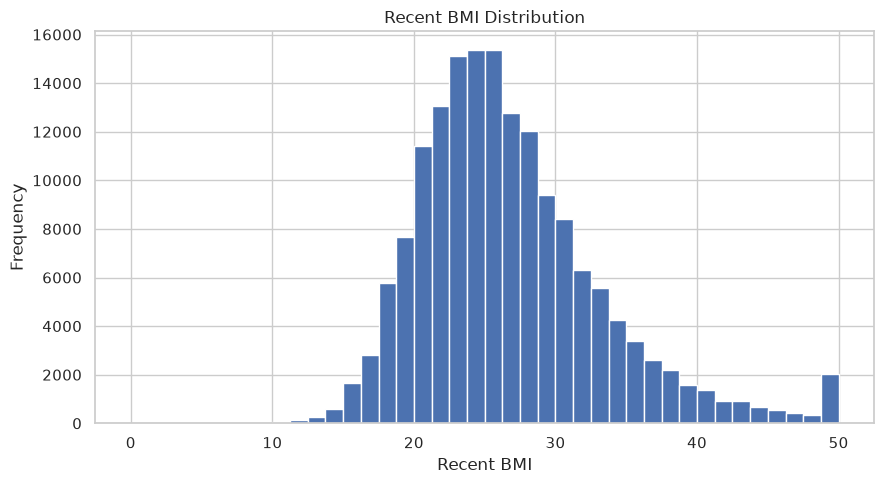

In [20]:

bmi = pd.to_numeric(df["recent_bmi"], errors="coerce")

print("Recent BMI summary:")
display(bmi.describe().to_frame("recent_bmi").round(2))

plt.figure(figsize=(9, 5))
plt.hist(bmi.dropna(), bins=40)
plt.xlabel("Recent BMI")
plt.ylabel("Frequency")
plt.title("Recent BMI Distribution")
plt.tight_layout()
plt.show()


## 12. Metadata consistency checks

In [21]:

# Check a few consistency relationships without treating them as clinical truth.

# Projection: AP/PA is usually meaningful for frontal images; quantify unexpected combinations.
projection_check = pd.crosstab(
    df["frontal_lateral"],
    df["ap_pa"],
    dropna=False
)
print("Frontal/Lateral × AP/PA:")
display(projection_check)

# Compare split in CSV vs split embedded in path.
if "path_split" in df.columns:
    mismatch = (
        df["split"].astype("string").fillna("<NA>")
        != df["path_split"].astype("string").fillna("<NA>")
    )
    print(f"CSV split vs path split mismatches: {mismatch.sum():,}")

# Compare metadata patient ID to patient ID parsed from image path.
patient_mismatch = (
    df["deid_patient_id"].astype("string").str.replace("patient", "", regex=False)
    != df["path_patient_id"].astype("string")
)
patient_mismatch = patient_mismatch & df["path_patient_id"].notna() & df["deid_patient_id"].notna()

print(f"Patient-ID parsing mismatches: {patient_mismatch.sum():,}")


Frontal/Lateral × AP/PA:


ap_pa,AP,LL,PA,RL,NaN
frontal_lateral,,,,,
Frontal,161622,16,29432,1,0
Lateral,0,0,0,0,32391


CSV split vs path split mismatches: 0
Patient-ID parsing mismatches: 0


## 13. Text-section availability summary

Your dedicated report/Findings/Impression EDA notebooks already analyze their content. Here we only record availability at the metadata level so the master notebook can describe dataset coverage.

In [22]:

text_sections = [
    "report",
    "section_narrative",
    "section_clinical_history",
    "section_history",
    "section_comparison",
    "section_technique",
    "section_procedure_comments",
    "section_findings",
    "section_impression",
    "section_end_of_impression",
    "section_summary",
    "section_accession_number",
]

availability = []
for col in text_sections:
    if col in df.columns:
        nonempty = df[col].notna() & df[col].astype("string").str.strip().ne("")
        availability.append({
            "section": col,
            "present": int(nonempty.sum()),
            "present_pct": float(nonempty.mean() * 100),
        })

availability_df = pd.DataFrame(availability).sort_values("present_pct", ascending=False)
display(availability_df.round(2))


,section,present,present_pct
0,report,223462,100.00
11,section_accession_number,223462,100.00
8,section_impression,223296,99.93
1,section_narrative,217922,97.52
4,section_comparison,213073,95.35
10,section_summary,189648,84.87
2,section_clinical_history,138860,62.14
7,section_findings,59441,26.60
3,section_history,38191,17.09
6,section_procedure_comments,25669,11.49


## 14. Optional X-ray image integrity and pixel-statistics EDA

Run this only if the local image files are available. The code samples a limited number of images so it does not attempt to load the full dataset into memory.

In [23]:

try:
    from PIL import Image
except ImportError:
    Image = None

if IMAGE_ROOT is None:
    print("IMAGE_ROOT is None — skipping image file EDA.")
elif Image is None:
    print("Pillow is not installed — install pillow to run image EDA.")
elif not IMAGE_ROOT.exists():
    print(f"Image root not found: {IMAGE_ROOT.resolve()}")
else:
    sample_df = df.sample(
        min(IMAGE_SAMPLE_N, len(df)),
        random_state=RANDOM_STATE
    )

    image_rows = []
    missing_files = 0
    unreadable_files = 0

    for rel_path in sample_df["path_to_image"].astype("string"):
        file_path = IMAGE_ROOT / str(rel_path)

        if not file_path.exists():
            missing_files += 1
            continue

        try:
            with Image.open(file_path) as img:
                gray = np.asarray(img.convert("L"))
                image_rows.append({
                    "path_to_image": str(rel_path),
                    "width": img.width,
                    "height": img.height,
                    "aspect_ratio": img.width / img.height if img.height else np.nan,
                    "mode": img.mode,
                    "mean_intensity": float(gray.mean()),
                    "std_intensity": float(gray.std()),
                    "min_intensity": int(gray.min()),
                    "max_intensity": int(gray.max()),
                })
        except Exception:
            unreadable_files += 1

    image_stats = pd.DataFrame(image_rows)

    print(f"Sampled image rows: {len(sample_df):,}")
    print(f"Readable images: {len(image_stats):,}")
    print(f"Missing files: {missing_files:,}")
    print(f"Unreadable files: {unreadable_files:,}")

    if not image_stats.empty:
        display(image_stats.describe(include="all").T)


Image root not found: /home/yash/Documents/Major/PNG


In [24]:

if 'image_stats' in globals() and not image_stats.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(image_stats["width"], bins=30)
    axes[0].set_title("Sampled X-ray Width Distribution")
    axes[0].set_xlabel("Width")
    axes[0].set_ylabel("Images")

    axes[1].hist(image_stats["height"], bins=30)
    axes[1].set_title("Sampled X-ray Height Distribution")
    axes[1].set_xlabel("Height")
    axes[1].set_ylabel("Images")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.scatter(
        image_stats["mean_intensity"],
        image_stats["std_intensity"],
        alpha=0.5
    )
    plt.xlabel("Mean grayscale intensity")
    plt.ylabel("Intensity standard deviation")
    plt.title("Sampled Image Intensity Statistics")
    plt.tight_layout()
    plt.show()
else:
    print("Run the previous image-statistics cell first.")


Run the previous image-statistics cell first.


## 15. Optional qualitative X-ray inspection

In [25]:

if (
    IMAGE_ROOT is not None
    and Image is not None
    and IMAGE_ROOT.exists()
):
    display_df = df.sample(
        min(12, len(df)),
        random_state=RANDOM_STATE
    )

    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    axes = axes.ravel()

    for ax, (_, row) in zip(axes, display_df.iterrows()):
        file_path = IMAGE_ROOT / str(row["path_to_image"])

        if file_path.exists():
            try:
                with Image.open(file_path) as img:
                    ax.imshow(img.convert("L"), cmap="gray")
                    ax.set_title(
                        f"{row['frontal_lateral']} | {row['ap_pa']}\n"
                        f"Age={row['age']} | Sex={row['sex']}"
                    )
            except Exception:
                ax.text(0.5, 0.5, "Unreadable", ha="center", va="center")
        else:
            ax.text(0.5, 0.5, "Missing", ha="center", va="center")

        ax.axis("off")

    for ax in axes[len(display_df):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Image root not available — skipping.")


Image root not available — skipping.


## 16. Optional integration with completed Report / Findings / Impression label EDA

Your three uploaded EDA notebooks already cover the section-specific label distributions. This section is intentionally optional: it expects exported CSVs rather than rebuilding those analyses.

In [26]:

def load_optional_labels(path, name):
    if path is None:
        print(f"{name}: not configured.")
        return None
    path = Path(path)
    if not path.exists():
        print(f"{name}: file not found -> {path}")
        return None
    x = pd.read_csv(path)
    print(f"{name}: {len(x):,} rows × {x.shape[1]:,} columns")
    return x

report_labels = load_optional_labels(REPORT_LABELS_PATH, "Report labels")
findings_labels = load_optional_labels(FINDINGS_LABELS_PATH, "Findings labels")
impression_labels = load_optional_labels(IMPRESSION_LABELS_PATH, "Impression labels")


Report labels: not configured.
Findings labels: not configured.
Impression labels: not configured.


## 17. Export metadata EDA summaries

In [27]:

OUTPUT_DIR = Path("chexpert_plus_eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

missing_summary.to_csv(OUTPUT_DIR / "metadata_missingness.csv")
availability_df.to_csv(OUTPUT_DIR / "report_section_availability.csv", index=False)

if 'study_counts' in globals():
    study_counts.rename("n_images").to_csv(
        OUTPUT_DIR / "images_per_study.csv",
        header=True
    )

if 'patient_image_counts' in globals():
    patient_image_counts.to_csv(
        OUTPUT_DIR / "images_per_patient.csv",
        header=True
    )

if 'image_stats' in globals() and not image_stats.empty:
    image_stats.to_csv(
        OUTPUT_DIR / "sampled_image_statistics.csv",
        index=False
    )

print(f"Saved EDA summaries to: {OUTPUT_DIR.resolve()}")


Saved EDA summaries to: /home/yash/Documents/Major/chexpert_plus_eda_outputs



# 18. Final EDA checklist

The master analysis now covers:

### Dataset structure
- [x] Exact 27-column schema validation
- [x] Row/column counts
- [x] Data types
- [x] Missingness

### Patient / study / image
- [x] Unique patients
- [x] Images per patient
- [x] Studies and images per study
- [x] Duplicate image paths
- [x] Image-path parsing

### Split / leakage
- [x] Split distribution
- [x] Patient membership across splits
- [x] Path-vs-CSV split consistency
- [x] Patient-ID consistency

### Imaging metadata
- [x] Frontal vs lateral
- [x] AP vs PA
- [x] Projection cross-tabulation
- [x] Optional image-file integrity
- [x] Optional image dimensions / pixel statistics
- [x] Optional qualitative image inspection

### Demographics
- [x] Age
- [x] Sex
- [x] Race
- [x] Ethnicity

### Clinical / administrative metadata
- [x] Recent BMI
- [x] Interpreter needed
- [x] Insurance type
- [x] Deceased status

### Reports
The detailed EDA for:
- Report
- Findings
- Impression

is already maintained in your three separate notebooks and is intentionally not duplicated here.

---

## Recommended next analysis

After this notebook is run, the most useful advanced analysis is **cross-modal linkage**:

```text
Patient
   ↓
Study
   ↓
X-ray
   ├── projection / image statistics
   └── report
       ├── Findings
       └── Impression
            ↓
       pathology labels
```

That is the point where the separate EDA notebooks become a single **multimodal CheXpert Plus analysis**.
